# Team Snack-ccident
- Ethan Dominic
- Alex Oh
- Dominic Tanzillo

# The Effect Size Files

In groups of 3, you will come up with a hypothesis-driven study to test your client’s claim. You should include a power analysis, where you calculate the required sample size for your study.

After you receive your claim:
- What are your null and alternative hypotheses?
- What statistical test will you perform?
- Explore literature to find effect size
- Perform power analysis w/ effect size
- Provide rationale for all decisions

## Deliverable:
PR of your Jupyter notebook with all analyses and justification into the week7 branch,


```
## SnackTrack App
Tracking your snacks in the app reduces mindless snacking episodes by 30% over two weeks.
Measure: snacking episodes (count).
```

## Hypotheses
Null Hypothesis: Tracking snacks in the app has less than a 30% reduction in mindless snacking episodes over two weeks (no significant deviation from the normal ampount of mindless snacking episodes over two weeks).


Alternative Hypothesis: Tracking snacks in the app has at least a 30% reduction in mindless snacking episodes over two weeks (there is a significant deviation from the normal amount of mindless snacking episodes over two weeks).

We defined these as our hypotheses since we are trying to prove that the app reduces mindless snacking episodes by 30% over two weeks (which we are considering as a significant reduction in this scenario).

## Statistical Test
We will be performing the Incidence Rate Ratio (IRR) statistical test, where IRR = (Incidence Rate (IR) in Exposed Group)/(Incidence Rate (IR) in Exposed Group) ← As defined by Gemini (from Google search made at 12:44 pm).


Incidence Rate Ratio (For Our Scenario):
IRR = (IR App Group) / (IR Control Group)

---

We determined IRR to be the best metric of our problem because it allows for measuring not just prevelance (i.e if someone snacked at all or not at all in the time window) but incidence. This allows for someone to snack multiple times in the 14 days to be captured as the total number of snacking episodes (snack-ccidents). In this manner, we can measure if snacking episodes is reduced rather than if someone stopped snacking. We are not asking for perfection just improvement.

> To snack is human, to forgive is divine.

# Literature Exploration to Find Effect Size
From https://www.ncss.com/wp-content/themes/ncss/pdf/Procedures/PASS/Tests_for_the_Difference_Between_Two_Poisson_Rates.pdf


And https://www.scribbr.com/statistics/poisson-distribution/

## Assumptions

To apply statistical tests, we will need to generate usable distributions. These will be Poisson Distributions which carry with it a number of assumpitons. It is simplest to thing of Poisson as determining around "arrivals." In this case, a snacking incident is considered an arrival. The assumptions needed are as follows:

- Arrivals are independent within each person
- There is a baseline distribution in the general population (later defined as $\lambda_0$) that is uniform across all people
- We consider this to be a continuous random variable and assume within each window (defined below in depth) as person-days (ex. 1 person-day is 1 person observed over 1 day) this probability holds
- Between our two distributions there is independence (i.e. someone from our control group snacking bears no relevance to someone snacking in our treatment \[given app\] group).
- We will have equal sample sizes in both groups because we are able to construct this study.

## Rationale

We measure events (snacking episodes) as counts per unit of time.


Notably this transforms our sampling into a continuous Poisson distribution.
For any Poisson process, the parameter $\lambda$ has both mean and variance equal to $\lambda$:


$$
\mathbb{E}[X] = \lambda, \qquad \mathrm{Var}(X) = \lambda.
$$

Therefore, we will have two Poisson distribution one for our control group which will result in incidence rate represented as $IR_0$ and $IRR_1$ for our treatment group (those given the app to control snacking).

$$
IR_0 = \frac{\text{total events in control}}{\text{total person-time in control}},
\qquad
IR_1 = \frac{\text{total events in treatment}}{\text{total person-time in treatment}}.
$$

The incidence rate ratio (IRR) is

$$
\text{IRR} = \frac{IR_1}{IR_0}.
$$


Taking the natural logarithm gives the effect size on the log scale:


$$
\log(\text{IRR}) = \log(IR_1) - \log(IR_0).
$$


### Per-subject parameterization / snacking
Let $\lambda_0$ be the control rate per unit time and $\lambda_1$ the treatment rate.
For follow-up time $t$ per subject, the average amount of snacking in control group is $\mu_0$ and control group is $\mu_1$:


$$
\mu_0 = \lambda_0 \cdot t,
\qquad
\mu_1 = \lambda_1 \cdot t.
$$




### Variance of the log rate ratio
For independent Poisson counts, the approximate variance is


$$
\mathrm{Var}\!\left[\log(\text{IRR})\right] \;\approx\; \frac{1}{\mu_0} + \frac{1}{\mu_1}.
$$




### Wald statistic
The test statistic for $H_0: \text{IRR} = 1$ is


$$
Z = \frac{\log(\text{IRR})}{\sqrt{\tfrac{1}{\mu_0} + \tfrac{1}{\mu_1}}}.
$$


Under $H_0$, this statistic follows approximately a standard normal distribution.




### Effect size for statsmodels
Define the standardized effect size $\delta$ as


$$
\delta = \frac{|\log(\text{IRR})|}{\sqrt{\tfrac{1}{\mu_0} + \tfrac{1}{\mu_1}}}.
$$


This $\delta$ is the quantity passed to
`statsmodels.stats.power.NormalIndPower.solve_power`
to calculate the required sample size.


## Power Analysis with Effect Size

In [ ]:
import numpy as np
from statsmodels.stats.power import NormalIndPower

cases = [] # Different sample sizes for each group (control and app) given differnt values of lamba0
for lambda0 in np.arange(0.1, 10.0,0.1):
  # Inputs
  alpha = 0.05 # Significance Level
  power_target = 0.80 # Power
  irr = 0.70          # 30% reduction
  t = 14              # follow-up days

  # Translate to rates
  lambda1 = irr * lambda0

  # Expected counts per person
  mu0 = lambda0 * t
  mu1 = lambda1 * t

  # Effect size is log(IRR) scaled by variance of log rate ratio
  log_irr = np.log(irr)

  # Variance of log(IRR) ≈ 1/mu0 + 1/mu1
  var_log = 1/mu0 + 1/mu1
  effect_size = abs(log_irr) / np.sqrt(var_log)

  # Use NormalIndPower (like you would for proportions)
  analysis = NormalIndPower()
  n_per_arm = analysis.solve_power(effect_size=effect_size,
                                  alpha=alpha,
                                  power=power_target,
                                  ratio=1,  # equal allocation
                                  alternative='two-sided')
  cases.append(n_per_arm)
#print(f"Required n per arm: {np.ceil(n_per_arm)}")

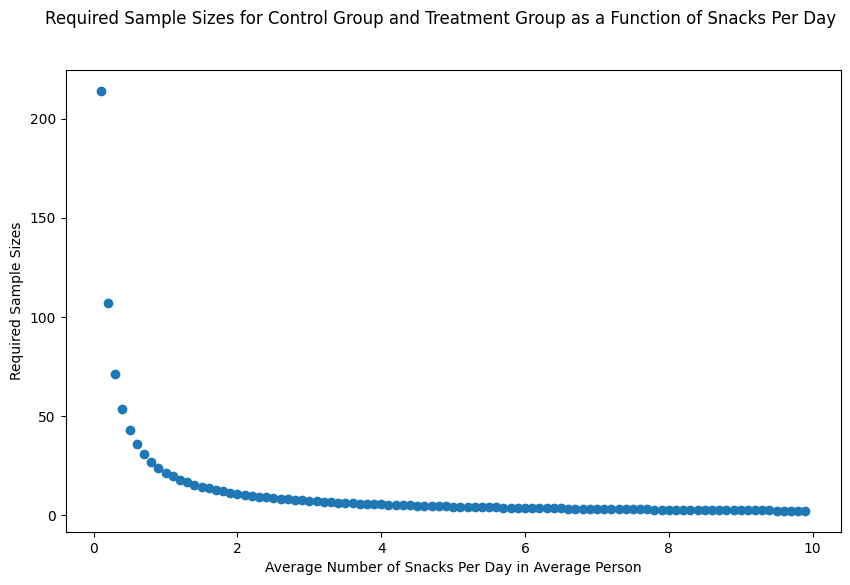

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(np.arange(0.1, 10.0,0.1), cases, marker='o')
plt.suptitle("Required Sample Sizes for Control Group and Treatment Group as a Function of Snacks Per Day")
plt.ylabel("Required Sample Sizes")
plt.xlabel("Average Number of Snacks Per Day in Average Person")

plt.show()